# Final Pipeline — Quantitative Trading and Price Impact

End-to-end pipeline structured around the `price_impact` module (`src/price_impact/`). The notebook is a thin orchestration layer; the heavy lifting lives in:

| Module | Responsibility |
|---|---|
| `data` | bin loading, ADV / σ, volume curves |
| `impact_states` | normalised $\bar I$ in **both** daily-reset and multi-day variants |
| `fitting` | parametric OLS, rolling baseline, non-parametric extension, half-life grid search |
| `alpha` | synthetic alpha (unbiased, target ρ — from `project.ipynb`) |
| `strategy` | OW, AFS, placeholder for time-dependent λ extended OW |
| `backtest` | Waelbroeck simulator accepting **generic** trade paths |
| `results` | per-day P&L, TCA decomposition, plotting |
| `runner` | `BacktestConfig` + `run_and_save` → `saved/<name>/` |

Each numbered section is one phase of the pipeline; the *Results* section runs multiple configurations in a small loop and writes everything to disk.


## 0. Setup


In [2]:
# from google.colab import drive

# drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# %cd "drive/My Drive/GoogleColab/price_impact_optimal_execution"
# %pip install -e . # Install the project in editable mode

/content/drive/My Drive/GoogleColab/price_impact_optimal_execution
Obtaining file:///content/drive/My%20Drive/GoogleColab/price_impact_optimal_execution
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for price-impact-optimal-execution (pyproject.toml) ... done
  Created wheel for price-impact-optimal-execution: filename=price_impact_optimal_execution-0.1.0-py3-none-any.whl size=1375 sha256=74c91206b1c0cb3d304096e607d56b8eb7c5b53c26ea4962de91629cb91fccd8
  Stored in directory: /tmp/pip-ephem-wheel-cache-0an3uctc/wheels/ac/c1/d3/4743e1feec0f1f21babe365d49859e63d671d0fa59d8b131ad
Successfully built price-impact-optimal-execution
  Attempting uninstall: price-impact-optimal-execution
    Found existing installation: price-impact-optimal-execution 0.1.0
    Uninstalling price-impact-optimal-execution-0.1.0:
     

In [1]:
import sys
from pathlib import Path

# Important: ensure auto-reloading is on so that changes to src/price_impact/
# are reflected automatically without having to restart the kernel.
%load_ext autoreload
%autoreload 2

# Folder layout: final_project/ holds the notebook + src/; the shared
# data/ directory lives at the project root, one level up.
ROOT = Path.cwd()
PROJECT_ROOT = ROOT
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

import price_impact as pi

print("price_impact modules:", [m for m in dir(pi) if not m.startswith("_")][:8], "...")

price_impact modules: ['BacktestConfig', 'BacktestResult', 'DaySimulation', 'ImpactModel', 'PanelData', 'RunOutput', 'afs_optimal_strategy', 'alpha'] ...


## 1. Data Preparation

Load monthly bin CSVs, restrict to the **top-20** stocks by total absolute order-flow volume, then compute trailing 20-day daily statistics ($\sigma_{i,d}$, $\mathrm{ADV}_{i,d}$).


In [2]:
DATA_DIR = PROJECT_ROOT / "data"
YEAR = 2019

panel = pi.build_panel(DATA_DIR, year=YEAR, top_n=20, lookback_days=20)
data = panel.bins
daily_stats = panel.daily_stats
print(
    f"panel: {panel.n_stocks} stocks, {data.shape[0]:,} bin rows, "
    f"{data['date'].nunique()} trading days"
)
daily_stats.head()

panel: 20 stocks, 11,028,752 bin rows, 250 trading days


sigma           ADV
stock date                              
AAL   2019-01-02  0.000498  6.914220e+05
      2019-01-03  0.000654  1.434520e+06
      2019-01-04  0.000621  1.413489e+06
      2019-01-07  0.000623  1.336470e+06
      2019-01-08  0.000611  1.261210e+06

**In-sample / out-of-sample split.** We use rolling monthly windows for the impact-model fitting (Section 3) and reserve the last few months for the backtest in Section 7.


In [3]:
data["month"] = pd.to_datetime(data["date"]).dt.month
print("Bin rows by month:")
print(data.groupby("month").size())


Bin rows by month:
month
1      924314
2      872426
3      961830
4      949533
5     1011602
6      912392
7      977871
8      972308
9      848418
10     982763
11     830026
12     785269
dtype: int64


## 2. Intraday Impact States

Compute the normalised impact state $\bar I_t$ from the OU recursion

$$ \bar I_{t+1} = (1-\beta)\,\bar I_t + \tilde q_t, \qquad \beta = \ln 2 / H_{\text{bins}}. $$

The module returns **both** variants on the same panel so downstream code can pick the one it needs:

- `I_bar_daily` — reset $\bar I \leftarrow 0$ at the start of each (stock, date);
- `I_bar_multi` — carry $\bar I$ across days within a stock, with an overnight decay applied between sessions.

We compute the panel once per (model, $H$) pair — Section 3 reuses this for the fitting and Section 7 reuses it for the backtest's reference impact.


In [4]:
H_FIT = 60.0  # half-life in minutes, will be revisited by the grid search
MODEL_TYPES = ("linear", "sqrt")

impact_panels = {
    mt: pi.compute_impact_states(
        data, daily_stats, half_life_minutes=H_FIT, model_type=mt
    )
    for mt in MODEL_TYPES
}

imp = impact_panels["linear"]
print("Columns:", imp.columns.tolist())
imp.head()


Columns: ['stock', 'date', 'time', 'q_tilde', 'I_bar_daily', 'I_bar_multi']


,stock,date,time,q_tilde,I_bar_daily,I_bar_multi
0,AAL,2019-01-02,09:30:00,2.448097e-08,2.448097e-08,2.448097e-08
1,AAL,2019-01-02,09:30:10,0.000000e+00,2.443383e-08,2.443383e-08
2,AAL,2019-01-02,09:30:20,-5.760227e-09,1.862656e-08,1.862656e-08
3,AAL,2019-01-02,09:30:30,-7.200284e-08,-5.341215e-08,-5.341215e-08
4,AAL,2019-01-02,09:30:40,1.440057e-07,9.069637e-08,9.069637e-08


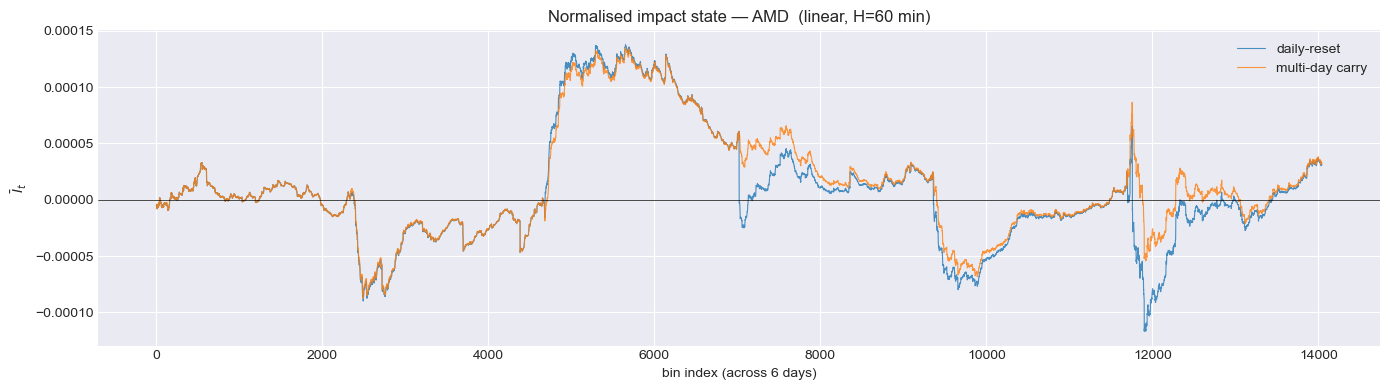

In [5]:
# Quick visual: daily-reset vs multi-day Ī for one (stock, range of dates).
stock_demo = panel.stocks[0]
sample = (
    imp[imp["stock"] == stock_demo].sort_values(["date", "time"]).head(2340 * 6)
)  # ~6 days
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample["I_bar_daily"].values, lw=0.8, label="daily-reset", alpha=0.8)
ax.plot(sample["I_bar_multi"].values, lw=0.8, label="multi-day carry", alpha=0.8)
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"Normalised impact state — {stock_demo}  (linear, H={H_FIT:.0f} min)")
ax.set_xlabel("bin index (across 6 days)")
ax.set_ylabel(r"$\bar I_t$")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Impact Model Fitting — Extended Analysis

Per Anran's Section 2.2: rolling per-stock OLS of $y_t = \alpha + \lambda x_t$ where

$$ y_t = (P_t - P_{t-\tau})/P_{t-\tau}, \qquad x_t = \bar I_t - \bar I_{t-\tau}. $$

The same machinery works on **either** carry mode — set `carry='daily'` or `carry='multi'` and the fitter consumes the right $\bar I$ column.


### 3.1 Half-life grid search


In [6]:
# Coarse grid; expand if needed. Daily-reset Ī is the standard for fitting.
H_GRID = [5, 10, 20, 30, 45, 60, 90, 120, 180]  # minutes
TAU_BINS = 6  # τ = 1 min explanation horizon (6 bins × 10 s/bin)

grid_df = pi.half_life_grid_search(
    data,
    daily_stats,
    H_grid_minutes=H_GRID,
    tau_bins=TAU_BINS,
    carry="daily",
    model_types=MODEL_TYPES,
    progress=True,
)
best_per_model = (
    grid_df.groupby(["model", "H"])["oos_r2"]
    .mean()
    .reset_index()
    .sort_values(["model", "oos_r2"], ascending=[True, False])
)
print(best_per_model.groupby("model").head(3).to_string(index=False))

H_star = int(np.mean(best_per_model.groupby("model")["H"].first()))
print(f"Adopted universal H* = {H_star} min")

 model  H   oos_r20 min .....
linear 45 0.150214
linear 60 0.150179
linear 30 0.150009
  sqrt 45 0.269565
  sqrt 30 0.269532
  sqrt 60 0.269179
Adopted universal H* = 45 min


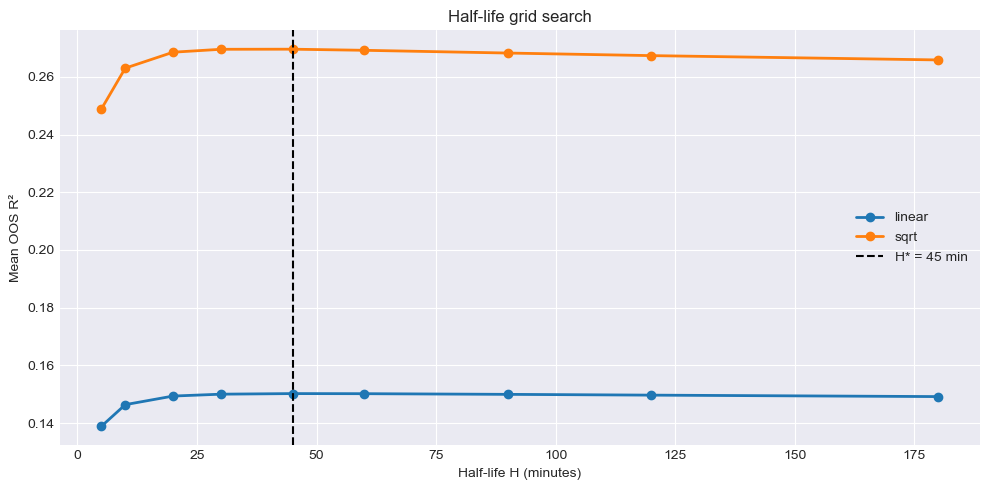

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for mt in MODEL_TYPES:
    sub = grid_df[grid_df["model"] == mt].groupby("H")["oos_r2"].mean()
    ax.plot(sub.index, sub.values, "o-", lw=2, label=mt)
ax.axvline(H_star, ls="--", color="black", label=f"H* = {H_star} min")
ax.set_xlabel("Half-life H (minutes)")
ax.set_ylabel("Mean OOS R²")
ax.set_title("Half-life grid search")
ax.legend()
plt.tight_layout()
plt.show()


### 3.2 Parametric rolling baseline — both carry modes


In [9]:
# Recompute impact panels at H* and fit on **both** carry modes so we can
# compare daily-reset vs multi-day Ī.
impact_panels_star = {
    mt: pi.compute_impact_states(data, daily_stats, H_star, model_type=mt)
    for mt in MODEL_TYPES
}

baseline_results = {}
for mt in MODEL_TYPES:
    for carry in ("daily", "multi"):
        feats = pi.build_regression_features(
            impact_panels_star[mt], data, tau_bins=TAU_BINS, carry=carry
        )
        stats = pi.daily_sufficient_stats(feats)
        baseline_results[(mt, carry)] = pi.rolling_baseline(
            stats, n_windows=10, offset=2
        )

summary_rows = []
for (mt, carry), df in baseline_results.items():
    mean_lam = df["lambda"].mean()
    sd_lam = df["lambda"].std()
    summary_rows.append(
        {
            "model": mt,
            "carry": carry,
            "mean_lambda": mean_lam,
            "sd_lambda": sd_lam,
            "t_stat_lambda": mean_lam / sd_lam if sd_lam > 0 else float("nan"),
            "mean_oos_r2": df["oos_r2"].mean(),
            "mean_is_r2": df["is_r2"].mean(),
            "n_rows": len(df),
        }
    )
pd.DataFrame(summary_rows).round(5)


,model,carry,mean_lambda,sd_lambda,t_stat_lambda,mean_oos_r2,mean_is_r2,n_rows
0,linear,daily,316.88254,76.18084,4.15961,0.15021,0.17419,196
1,linear,multi,315.53816,75.87537,4.15864,0.14949,0.17346,196
2,sqrt,daily,20.18736,3.30172,6.11419,0.26956,0.27619,196
3,sqrt,multi,20.12818,3.29057,6.11693,0.26876,0.27541,196


### 3.3 Non-parametric binned extension


In [10]:
# Per-stock binned g(x) shrunk toward a universal curve; γ tuned on the
# month immediately after the training month, OOS scored on m + 2.
feats_lin = pi.build_regression_features(
    impact_panels_star["linear"], data, tau_bins=TAU_BINS, carry="daily"
)
feats_sq = pi.build_regression_features(
    impact_panels_star["sqrt"], data, tau_bins=TAU_BINS, carry="daily"
)

np_lin, fits_lin = pi.rolling_nonparametric(feats_lin, n_bins=15, n_windows=10)
np_sq, fits_sq = pi.rolling_nonparametric(feats_sq, n_bins=15, n_windows=10)

comparison = (
    pd.concat(
        [
            np_lin.assign(model="linear"),
            np_sq.assign(model="sqrt"),
        ]
    )
    .groupby("model")[["oos_r2_raw", "oos_r2_univ", "oos_r2_reg"]]
    .mean()
)
print("OOS R² (mean over windows):")
print(comparison.round(5))


OOS R² (mean over windows):
        oos_r2_raw  oos_r2_univ  oos_r2_reg
model                                      
linear     0.23172      0.22050     0.23192
sqrt       0.27148      0.26482     0.27152


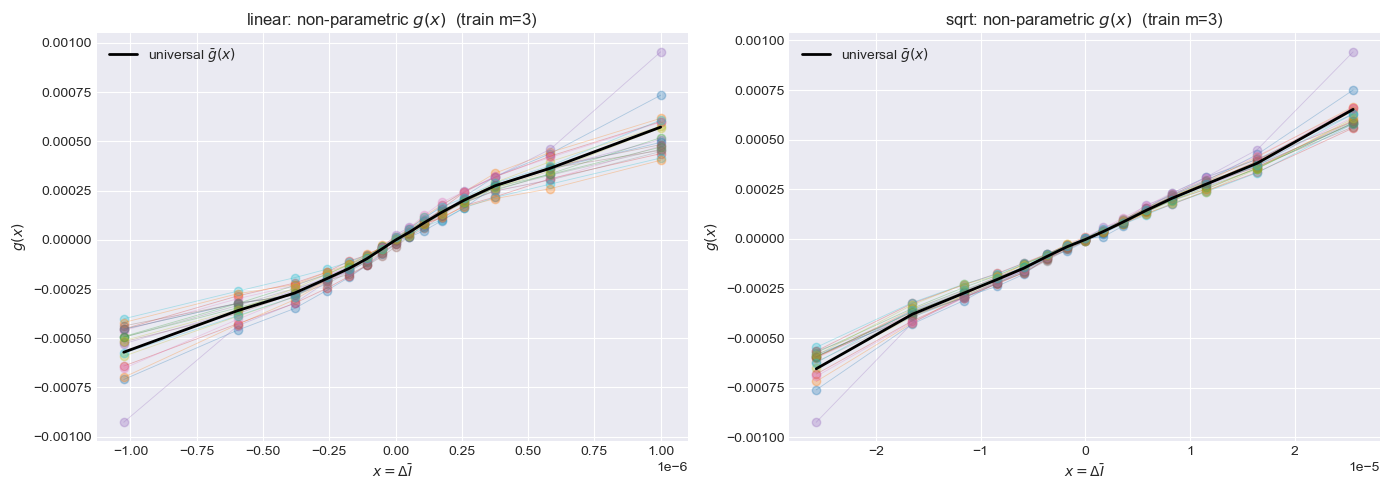

In [11]:
# Estimated impact curves for one window (train month = 3).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mt, fits in zip(axes, MODEL_TYPES, [fits_lin, fits_sq]):
    if 3 not in fits:
        ax.set_title(f"{mt}: no fit for month 3")
        continue
    f = fits[3]
    edges = f.bin_edges
    centers = 0.5 * (edges[:-1] + edges[1:])
    centers[0] = edges[1] - (edges[2] - edges[1])
    centers[-1] = edges[-2] + (edges[-2] - edges[-3])
    for stock, g in f.reg_best.groupby("stock"):
        ax.plot(centers[g["bin"]], g["g_reg"], "o-", lw=0.6, alpha=0.3)
    ax.plot(
        centers,
        f.g_bar.reindex(range(len(centers))).values,
        "k-",
        lw=2,
        label="universal $\\bar g(x)$",
    )
    ax.set_xlabel(r"$x = \Delta \bar I$")
    ax.set_ylabel(r"$g(x)$")
    ax.set_title(f"{mt}: non-parametric $g(x)$  (train m=3)")
    ax.legend()
plt.tight_layout()
plt.show()


### 3.4 Per-stock λ for the backtest


In [12]:
# Use the mean λ over rolling windows for each (model, carry) combination.
# These dicts feed `BacktestConfig` in Section 7.
lam_lookup_daily = {
    mt: pi.per_stock_lambda(baseline_results[(mt, "daily")]).to_dict()
    for mt in MODEL_TYPES
}
lam_lookup_multi = {
    mt: pi.per_stock_lambda(baseline_results[(mt, "multi")]).to_dict()
    for mt in MODEL_TYPES
}

print("Per-stock λ (linear, daily-reset) stats:")
print(
    pi.per_stock_lambda_stats(baseline_results[("linear", "daily")])
    .sort_values("mean")
    .round(5)
    .to_string()
)


Per-stock λ (linear, daily-reset) stats:
            mean       std    t_stat
stock                               
AES    198.31272  14.15168  14.01337
AEP    249.45484  87.98357   2.83524
AAL    250.35796  58.40140   4.28685
AMAT   279.51778  56.17457   4.97588
APC    282.97286  81.00471   3.49329
ADI    285.15963  35.81180   7.96273
ADP    295.15631  49.42199   5.97217
AOS    303.29099  63.51792   4.77489
ADSK   315.67878  68.88843   4.58246
ABT    320.51887  54.49963   5.88112
ADM    328.53534  24.84950  13.22100
AIG    329.98873  66.74969   4.94367
ABBV   331.11326  55.35684   5.98143
APA    335.84468  60.05106   5.59265
ADBE   337.14289  48.96697   6.88511
AMGN   349.15123  60.27633   5.79251
AMD    357.80475  59.83781   5.97958
AFL    358.62632  58.14424   6.16787
AAPL   380.43704  94.35390   4.03202
AMZN   435.02203  48.29382   9.00782


## 4. Synthetic Alpha

$\alpha_t = r^h_t + y \, dW_t / P_t$ with $y$ chosen so that $\mathrm{Corr}(\alpha, r^h) = \rho$ **and** $E[r^h | \alpha] = \alpha$.


In [ ]:
RHO = 0.05
H_ALPHA_BINS = 1  # next-bin forward return

alphas = pi.create_synthetic_alpha(
    data, rho=RHO, h_bins=H_ALPHA_BINS, seed=42, verbose=False
)
emp = alphas.groupby("stock").apply(lambda g: g["alpha"].corr(g["fwd_ret"]))
print(f"Empirical mean Corr(α, r) = {emp.mean():.4f}  (target ρ = {RHO})")
alphas.head()


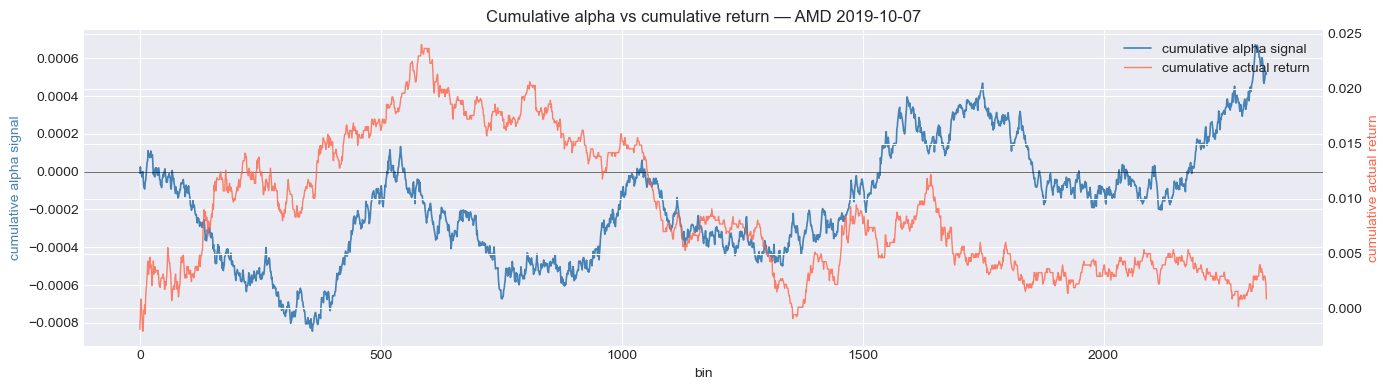

In [21]:
demo_stock = panel.stocks[0]
demo_date = alphas["date"].iloc[len(alphas) // 2]
mask = (alphas["stock"] == demo_stock) & (alphas["date"] == demo_date)
day = alphas.loc[mask].reset_index(drop=True)

cum_alpha = day["alpha"].cumsum()
cum_ret = day["fwd_ret"].cumsum()

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.plot(cum_alpha.values, color="steelblue", lw=1.2, label="cumulative alpha signal")
ax2.plot(
    cum_ret.values, color="tomato", lw=1.0, alpha=0.8, label="cumulative actual return"
)

ax1.axhline(0, color="k", lw=0.4)
ax1.set_xlabel("bin")
ax1.set_ylabel("cumulative alpha signal", color="steelblue")
ax2.set_ylabel("cumulative actual return", color="tomato")
ax1.set_title(
    f"Cumulative alpha vs cumulative return — {demo_stock} {demo_date.date()}"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()

### Optimal trading strategies

**OW.** Closed-form OW target position:

$$
X_t^* = \frac{\alpha_t \, ADV}{2 \lambda \sigma}
$$

The position is adjusted at speed

$$
\kappa = \beta = \frac{\log(2)}{H}
$$

with the practical final-30-minute ramp used in the implementation.

**AFS.** With constant alpha, the AFS target is set in impact space:

$$
I_t^* = \frac{\alpha_t}{1+c}
$$

Since realized impact is $I_t = \lambda \bar I_t$, the normalized target state is

$$
\bar I_t^* = \frac{\alpha_t}{(1+c)\lambda}
$$

For sqrt AFS, $c = 0.5$, so $I_t^* = 2\alpha_t/3$. Trades are recovered by inverting the normalized square-root recursion:

$$
\bar I_t = (1-\beta)\bar I_{t-1}
+ \sigma \, \mathrm{sign}(q_t)
\sqrt{\frac{|q_t|}{ADV}}
$$

Define

$$
z_t = \bar I_t^* - (1-\beta)\bar I_{t-1}
$$

Then the AFS trade per bin is

$$
q_t^* = ADV \, \mathrm{sign}(z_t)
\left(\frac{|z_t|}{\sigma}\right)^2
$$

The same practical end-of-day ramp convention is applied as in OW.

AMD 2019-10-07:  OW Σ|q| = 1715, AFS Σ|q| = 228


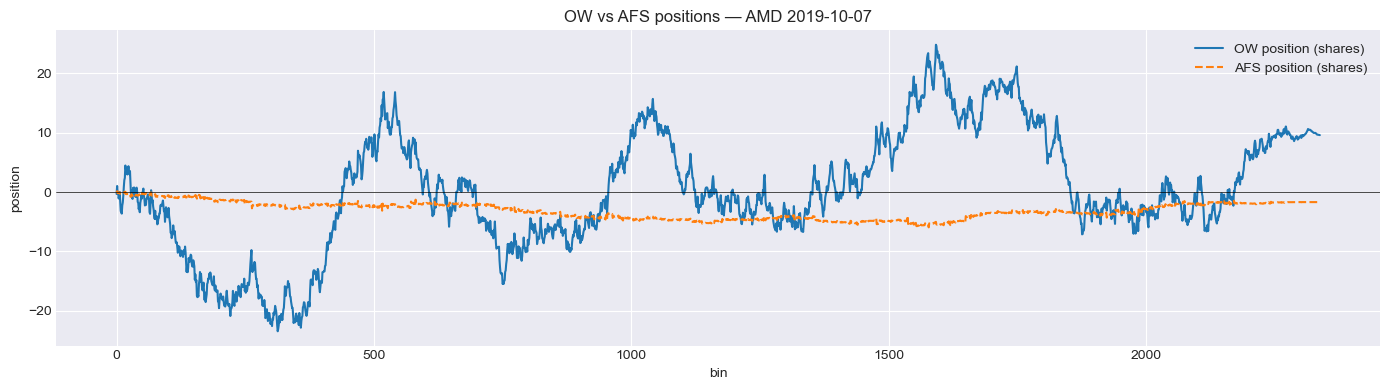

In [22]:
# Sanity check on a synthetic-alpha day.
demo_stock = panel.stocks[0]
demo_date = alphas["date"].iloc[len(alphas) // 2]
mask = (alphas["stock"] == demo_stock) & (alphas["date"] == demo_date)
alpha_demo = alphas.loc[mask, "alpha"].values
stats_demo = daily_stats.loc[(demo_stock, demo_date)]
lam_demo = lam_lookup_daily["linear"][demo_stock]

q_ow = pi.ow_optimal_strategy(
    alpha_demo,
    stats_demo["sigma"],
    stats_demo["ADV"],
    lam=lam_demo,
    half_life_minutes=H_star,
)
q_afs = pi.afs_optimal_strategy(
    alpha_demo,
    stats_demo["sigma"],
    stats_demo["ADV"],
    lam=lam_demo,
    half_life_minutes=H_star,
)
print(
    f"{demo_stock} {demo_date.date()}:  "
    f"OW Σ|q| = {np.sum(np.abs(q_ow)):.0f}, AFS Σ|q| = {np.sum(np.abs(q_afs)):.0f}"
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(np.cumsum(q_ow), label="OW position (shares)")
ax.plot(np.cumsum(q_afs), label="AFS position (shares)", ls="--")
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"OW vs AFS positions — {demo_stock} {demo_date.date()}")
ax.set_xlabel("bin")
ax.set_ylabel("position")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Backtest Engine

Waelbroeck construction with explicit flow accounting:

$$ q_{others,t} = q_{agg,t} - q_{us,t}, \qquad g_{others}(t)=\lambda\bar I(q_{others})(t), \qquad g_{full}(t)=\lambda\bar I(q_{agg})(t). $$

Both price paths share the same baseline cumulative return $R(t)$ from the day-open mid:

$$ P_{unpert}(t)=P_0\bigl(1+R(t)+g_{others}(t)\bigr), \qquad P_{pert}(t)=P_0\bigl(1+R(t)+g_{full}(t)\bigr). $$

The incremental model impact of our trading is $\Delta g(t)=g_{full}(t)-g_{others}(t)$. Mark-to-market net P&L uses `P_pert`; the no-us benchmark uses `P_unpert`; raw observed mid P&L is retained only as a diagnostic. Participation is computed from `abs(q_us) / abs(trade)` per bin and from turnover over day volume.

`run_backtest` accepts **any** signed trade path through a `trade_provider` callable; pass `make_optimal_provider(...)` for OW/AFS, or `make_fixed_provider(...)` for TWAP / VWAP demos. Carry mode is `daily` or `multi`: daily resets impact to zero at each open, while multi-day starts `I_others` and `I_full` exactly where they ended on the previous trading day, with no overnight impact decay.

Reality check: `P_unpert` is a Waelbroeck-consistent counterfactual, not an observed no-us mid. The rolling-stat functions can consume `price_col="p_unpert"` when such a panel exists; the first-pass historical calibration here remains mid-based and is therefore an explicit hybrid.


## 7. Results — Modular Backtest Sweep

We compare four configurations along two axes — model (OW vs AFS) × carry mode (daily-reset vs multi-day). Each run produces:

- per-day P&L on `P_pert` and `P_unpert`, plus raw-mid diagnostics;
- turnover, realised participation, max with-us/no-us impact dislocation, and flow-accounting flags where `abs(q_us) > abs(q_agg)` in a bin;
- TCA decomposition (net P&L, gross no-us P&L, impact cost, predicted α reward, realised α reward);
- cumulative-P&L, drawdown, and impact-dislocation plots.

All artifacts land in `saved/<name>/`.


In [ ]:
configs = [
    pi.BacktestConfig(
        name="ow_daily",
        model_type="linear",
        strategy="ow",
        carry="daily",
        half_life_minutes=H_star,
        tau_bins=TAU_BINS,
        rho=RHO,
        h_alpha_bins=H_ALPHA_BINS,
    ),
    pi.BacktestConfig(
        name="ow_multi",
        model_type="linear",
        strategy="ow",
        carry="multi",
        half_life_minutes=H_star,
        tau_bins=TAU_BINS,
        rho=RHO,
        h_alpha_bins=H_ALPHA_BINS,
    ),
    pi.BacktestConfig(
        name="afs_daily",
        model_type="sqrt",
        strategy="afs",
        carry="daily",
        half_life_minutes=H_star,
        tau_bins=TAU_BINS,
        rho=RHO,
        h_alpha_bins=H_ALPHA_BINS,
    ),
    pi.BacktestConfig(
        name="afs_multi",
        model_type="sqrt",
        strategy="afs",
        carry="multi",
        half_life_minutes=H_star,
        tau_bins=TAU_BINS,
        rho=RHO,
        h_alpha_bins=H_ALPHA_BINS,
    ),
    pi.BacktestConfig(
        name="afs_pi_linear_strat_daily",
        model_type="sqrt",
        strategy="linear",
        carry="daily",
        half_life_minutes=H_star,
        tau_bins=TAU_BINS,
        rho=RHO,
        h_alpha_bins=H_ALPHA_BINS,
    ),
    pi.BacktestConfig(
        name="afs_pi_linear_strat_multi",
        model_type="sqrt",
        strategy="linear",
        carry="multi",
        half_life_minutes=H_star,
        tau_bins=TAU_BINS,
        rho=RHO,
        h_alpha_bins=H_ALPHA_BINS,
    ),
]

runs = {}
for cfg in configs:
    lam_lookup = (lam_lookup_daily if cfg.carry == "daily" else lam_lookup_multi)[
        cfg.model_type
    ]
    sample_day = (panel.stocks[0], alphas["date"].iloc[len(alphas) // 2])
    out = pi.run_and_save(
        data, daily_stats, alphas, lam_lookup, cfg, sample_path=sample_day
    )
    runs[cfg.name] = out
    print(
        f"{cfg.name:12s}  Sharpe(pert)={out.metrics['sharpe_pert']:+.3f}  "
        f"net P&L=${out.metrics['total_pnl_pert']:>14,.0f}  "
        f"impact cost=${out.metrics['total_impact_cost']:>14,.0f}  "
        f"participation={out.metrics['realized_participation']:.4%}  "
        f"flow flags={out.metrics['flow_flag_count']:d}"
    )


ow_daily      Sharpe(pert)=+2.019  net P&L=$         1,589  impact cost=$             2  participation=0.0341%  flow flags=410775
ow_multi      Sharpe(pert)=+1.027  net P&L=$         5,538  impact cost=$             3  participation=0.0356%  flow flags=410779
afs_daily     Sharpe(pert)=+2.462  net P&L=$        59,098  impact cost=$         7,031  participation=1.0401%  flow flags=476733
afs_multi     Sharpe(pert)=+0.123  net P&L=$        24,966  impact cost=$         7,696  participation=1.1022%  flow flags=478912
afs_pi_linear_strat_daily  Sharpe(pert)=+1.913  net P&L=$        23,422  impact cost=$         1,464  participation=0.5153%  flow flags=442173


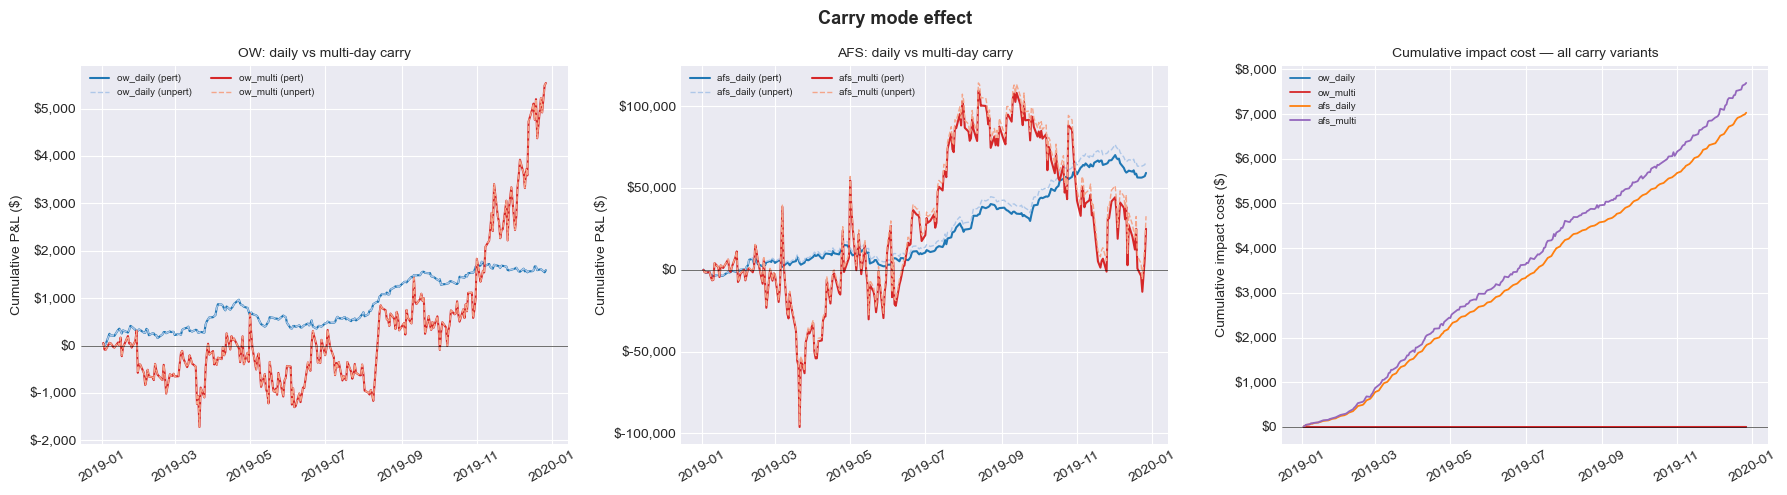

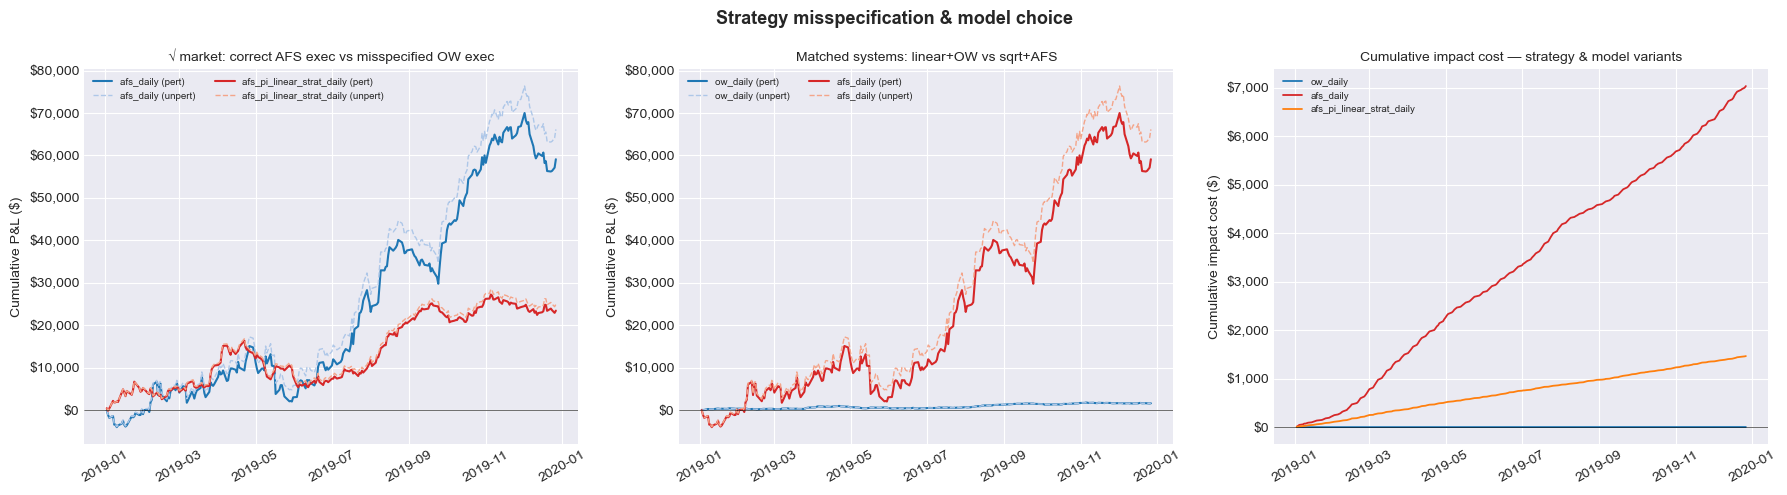

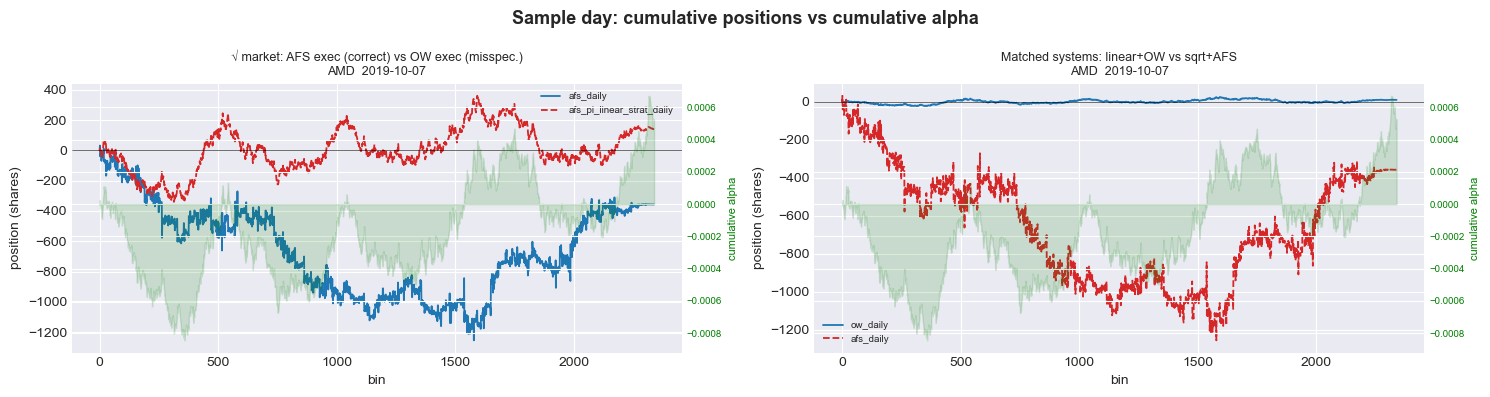

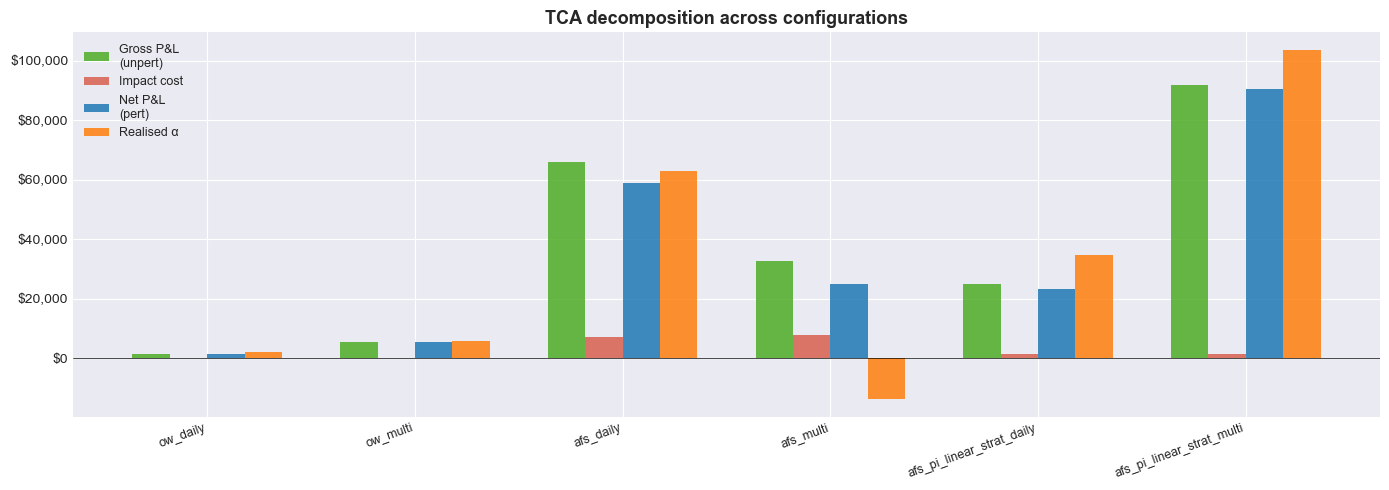

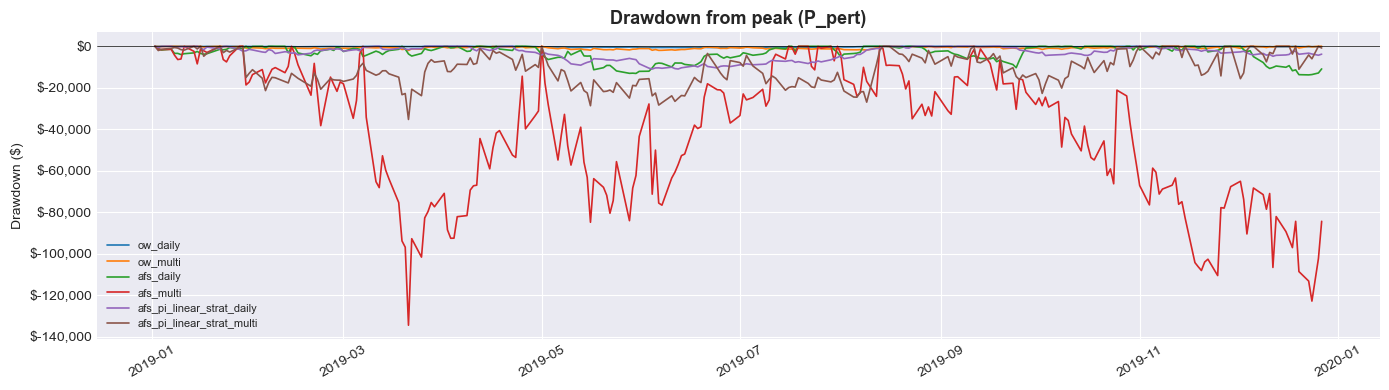

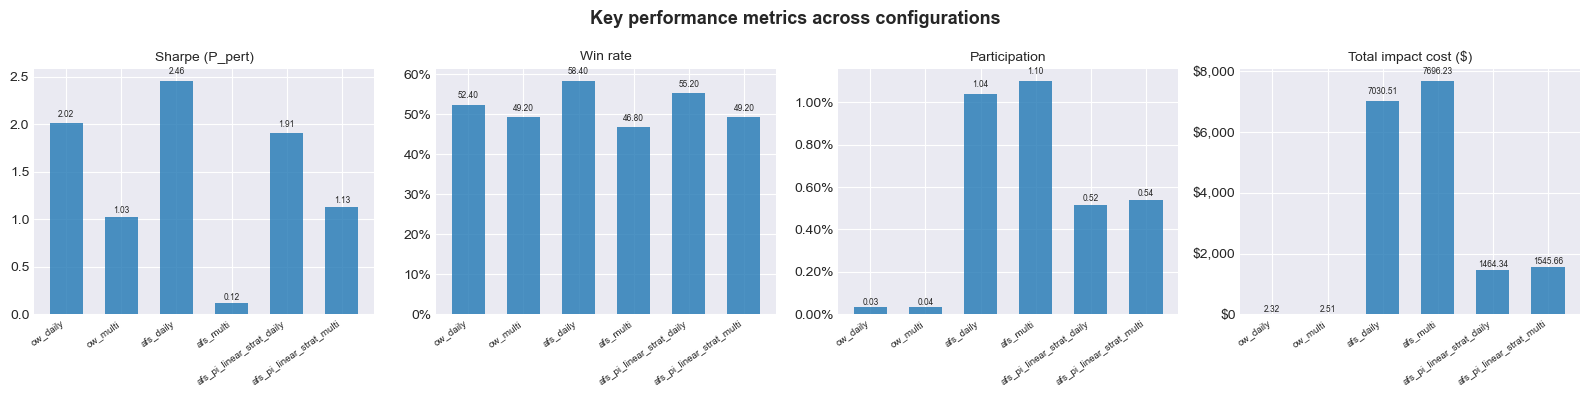

In [28]:
import matplotlib.ticker as mtick


# ─── helpers ──────────────────────────────────────────────────────────────────
def _cum(name, col="pnl_pert"):
    return pi.cumulative_pnl(runs[name].daily, col)


_CA = ("#1f77b4", "#aec7e8")  # pert / unpert for run A
_CB = ("#d62728", "#f4a58a")  # pert / unpert for run B
_IMPACT_PALETTE = ["#1f77b4", "#d62728", "#ff7f0e", "#9467bd", "#2ca02c", "#8c564b"]


def _pair_ax(ax, nameA, nameB, title):
    for name, (cp_col, cu_col) in [(nameA, _CA), (nameB, _CB)]:
        cp = _cum(name, "pnl_pert")
        cu = _cum(name, "pnl_unpert")
        ax.plot(cp.index, cp.values, color=cp_col, lw=1.5, label=f"{name} (pert)")
        ax.plot(
            cu.index, cu.values, color=cu_col, lw=1.0, ls="--", label=f"{name} (unpert)"
        )
    ax.axhline(0, color="k", lw=0.4)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Cumulative P&L ($)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=7, ncol=2)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"${v:,.0f}"))


def _impact_ax(ax, names, title):
    for name, c in zip(names, _IMPACT_PALETTE):
        ci = _cum(name, "impact_cost")
        ax.plot(ci.index, ci.values, color=c, lw=1.3, label=name)
    ax.axhline(0, color="k", lw=0.4)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Cumulative impact cost ($)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=7)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"${v:,.0f}"))


# ─── Figure 1: carry-mode effect ──────────────────────────────────────────────
# Q: does carrying Ī across days help or hurt — for OW and AFS separately?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
_pair_ax(axes[0], "ow_daily", "ow_multi", "OW: daily vs multi-day carry")
_pair_ax(axes[1], "afs_daily", "afs_multi", "AFS: daily vs multi-day carry")
_impact_ax(
    axes[2],
    ["ow_daily", "ow_multi", "afs_daily", "afs_multi"],
    "Cumulative impact cost — all carry variants",
)
fig.suptitle("Carry mode effect", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ─── Figure 2: strategy misspecification + model choice ───────────────────────
# afs_pi_linear_strat: TRUE market impact is AFS (√), but we optimise as if
# linear (OW). Left panel isolates the strategy-misspecification cost; right
# panel compares the two fully-matched systems.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
_pair_ax(
    axes[0],
    "afs_daily",
    "afs_pi_linear_strat_daily",
    "√ market: correct AFS exec vs misspecified OW exec",
)
_pair_ax(axes[1], "ow_daily", "afs_daily", "Matched systems: linear+OW vs sqrt+AFS")
_impact_ax(
    axes[2],
    ["ow_daily", "afs_daily", "afs_pi_linear_strat_daily"],
    "Cumulative impact cost — strategy & model variants",
)
fig.suptitle("Strategy misspecification & model choice", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ─── Figure 3: sample day — positions + cumulative alpha ──────────────────────
# Alpha shown cumulatively (sum of per-bin signals) so both axes are in the
# same direction-of-drift sense. Carry pairs omitted: intraday positions are
# identical without reconstructing the cross-day Ī carry state.
_s_stock = panel.stocks[0]
_s_date = alphas["date"].iloc[len(alphas) // 2]
_s_mask = (alphas["stock"] == _s_stock) & (alphas["date"] == _s_date)
_s_alpha = alphas.loc[_s_mask, "alpha"].values
_s_cum_alpha = np.cumsum(_s_alpha)
_s_stats = daily_stats.loc[(_s_stock, _s_date)]

_day_pairs = [
    # Misspecification: same √ model, AFS strategy (correct) vs OW strategy (wrong)
    (
        "afs_daily",
        pi.afs_optimal_strategy,
        lam_lookup_daily["sqrt"][_s_stock],
        "afs_pi_linear_strat_daily",
        pi.ow_optimal_strategy,
        lam_lookup_daily["sqrt"][_s_stock],
        "√ market: AFS exec (correct) vs OW exec (misspec.)",
    ),
    # Matched systems: linear+OW vs sqrt+AFS
    (
        "ow_daily",
        pi.ow_optimal_strategy,
        lam_lookup_daily["linear"][_s_stock],
        "afs_daily",
        pi.afs_optimal_strategy,
        lam_lookup_daily["sqrt"][_s_stock],
        "Matched systems: linear+OW vs sqrt+AFS",
    ),
]

fig, axes = plt.subplots(1, len(_day_pairs), figsize=(15, 4))
for ax, (nA, fnA, lamA, nB, fnB, lamB, title) in zip(axes, _day_pairs):
    posA = np.cumsum(fnA(_s_alpha, _s_stats["sigma"], _s_stats["ADV"], lamA, H_star))
    posB = np.cumsum(fnB(_s_alpha, _s_stats["sigma"], _s_stats["ADV"], lamB, H_star))
    ax2 = ax.twinx()
    ax2.fill_between(range(len(_s_cum_alpha)), _s_cum_alpha, alpha=0.15, color="green")
    ax2.set_ylabel("cumulative alpha", color="green", fontsize=8)
    ax2.tick_params(axis="y", labelcolor="green", labelsize=7)
    ax.plot(posA, color=_CA[0], lw=1.3, label=nA)
    ax.plot(posB, color=_CB[0], lw=1.3, ls="--", label=nB)
    ax.axhline(0, color="k", lw=0.4)
    ax.set_xlabel("bin")
    ax.set_ylabel("position (shares)")
    ax.set_title(f"{title}\n{_s_stock}  {_s_date.date()}", fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle(
    "Sample day: cumulative positions vs cumulative alpha",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# ─── Figure 4: TCA decomposition bar chart ────────────────────────────────────
_tca = pd.DataFrame({n: pi.tca_summary(r.tca) for n, r in runs.items()}).T
_tca_cols = ["gross_pnl", "impact_cost", "net_pnl", "realised_alpha"]
_tca_labels = ["Gross P&L\n(unpert)", "Impact cost", "Net P&L\n(pert)", "Realised α"]
_tca_colors = ["#4dac26", "#d6604d", "#1f77b4", "#ff7f0e"]

_x, _w = np.arange(len(_tca)), 0.18
fig, ax = plt.subplots(figsize=(14, 5))
for i, (col, lbl, c) in enumerate(zip(_tca_cols, _tca_labels, _tca_colors)):
    ax.bar(_x + i * _w, _tca[col], _w, label=lbl, color=c, alpha=0.85)
ax.set_xticks(_x + 1.5 * _w)
ax.set_xticklabels(_tca.index, rotation=20, ha="right", fontsize=9)
ax.axhline(0, color="k", lw=0.5)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"${v:,.0f}"))
ax.set_title("TCA decomposition across configurations", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ─── Figure 5: drawdown from peak ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
for name in runs:
    c = _cum(name, "pnl_pert")
    ax.plot(c.index, (c - c.cummax()).values, lw=1.2, label=name)
ax.axhline(0, color="k", lw=0.5)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"${v:,.0f}"))
ax.set_title("Drawdown from peak (P_pert)", fontsize=13, fontweight="bold")
ax.set_ylabel("Drawdown ($)")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ─── Figure 6: key performance metrics ───────────────────────────────────────
_met_specs = [
    ("sharpe_pert", "Sharpe (P_pert)", 1, None),
    ("win_rate", "Win rate", 100, "%"),
    ("realized_participation", "Participation", 100, "%"),
    ("total_impact_cost", "Total impact cost ($)", 1, "$"),
]
_names = list(runs.keys())
_x2 = np.arange(len(_names))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (metric, lbl, scale, fmt) in zip(axes, _met_specs):
    vals = [runs[n].metrics[metric] * scale for n in _names]
    bars = ax.bar(_x2, vals, color="#1f77b4", alpha=0.8, width=0.6)
    ax.set_xticks(_x2)
    ax.set_xticklabels(_names, rotation=35, ha="right", fontsize=7)
    ax.set_title(lbl, fontsize=10)
    if fmt == "%":
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    elif fmt == "$":
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"${v:,.0f}"))
    for bar, v in zip(bars, vals):
        va = "bottom" if v >= 0 else "top"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * (1.02 if v >= 0 else 0.98),
            f"{v:.2f}",
            ha="center",
            va=va,
            fontsize=6,
        )
fig.suptitle(
    "Key performance metrics across configurations", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

### 7.1 Comparison table


In [ ]:
comparison = pd.DataFrame({name: r.metrics for name, r in runs.items()}).T
comparison[
    [
        "n_days",
        "sharpe_pert",
        "sharpe_unpert",
        "sharpe_mid_raw",
        "total_pnl_pert",
        "total_pnl_unpert",
        "total_pnl_mid_raw",
        "total_impact_cost",
        "realized_participation",
        "flow_flag_count",
        "max_drawdown",
        "max_impact_dislocation",
        "win_rate",
    ]
].round(4)


,n_days,sharpe_pert,sharpe_unpert,sharpe_mid_raw,total_pnl_pert,total_pnl_unpert,total_pnl_mid_raw,total_impact_cost,realized_participation,flow_flag_count,max_drawdown,max_impact_dislocation,win_rate
ow_daily,250,3.72541,3.824743,5.15402,139651.493805,143391.001222,131158.941566,3739.507417,0.02402,560268,-17571.322449,0.000071,0.616
ow_multi,250,1.642074,1.654749,1.882173,460762.982411,464342.580142,458384.903414,3579.59773,0.024071,560625,-105667.617683,0.000069,0.552
afs_daily,250,3.697377,3.925081,5.162655,134534.151183,142809.938458,133994.976769,8275.787275,0.024764,563567,-18451.594127,0.00041,0.6
afs_multi,250,1.795763,1.825312,2.142185,495598.138375,503762.704785,508584.434094,8164.56641,0.024767,563579,-106618.237538,0.000391,0.572


### 7.2 TCA decomposition


In [ ]:
tca_rows = {name: pi.tca_summary(r.tca) for name, r in runs.items()}
tca_summary_df = pd.DataFrame(tca_rows).T
tca_summary_df[
    [
        "gross_pnl",
        "impact_cost",
        "net_pnl",
        "mid_raw_pnl",
        "predicted_alpha",
        "realised_alpha",
        "turnover",
        "gross_notional",
        "flow_flag_count",
    ]
].round(2)


,gross_pnl,impact_cost,net_pnl,mid_raw_pnl,predicted_alpha,realised_alpha,turnover,gross_notional,flow_flag_count
ow_daily,143391.00,3739.51,139651.49,131158.94,50957110.45,131135.33,95968758.94,1.172615e+10,560268.0
ow_multi,464342.58,3579.60,460762.98,458384.90,50964710.61,427838.06,96172959.80,1.175191e+10,560625.0
afs_daily,142809.94,8275.79,134534.15,133994.98,51028877.54,134000.38,98942225.28,1.207852e+10,563567.0
afs_multi,503762.70,8164.57,495598.14,508584.43,51028597.77,479543.37,98953773.91,1.208005e+10,563579.0


### 7.3 Cumulative P&L — head-to-head


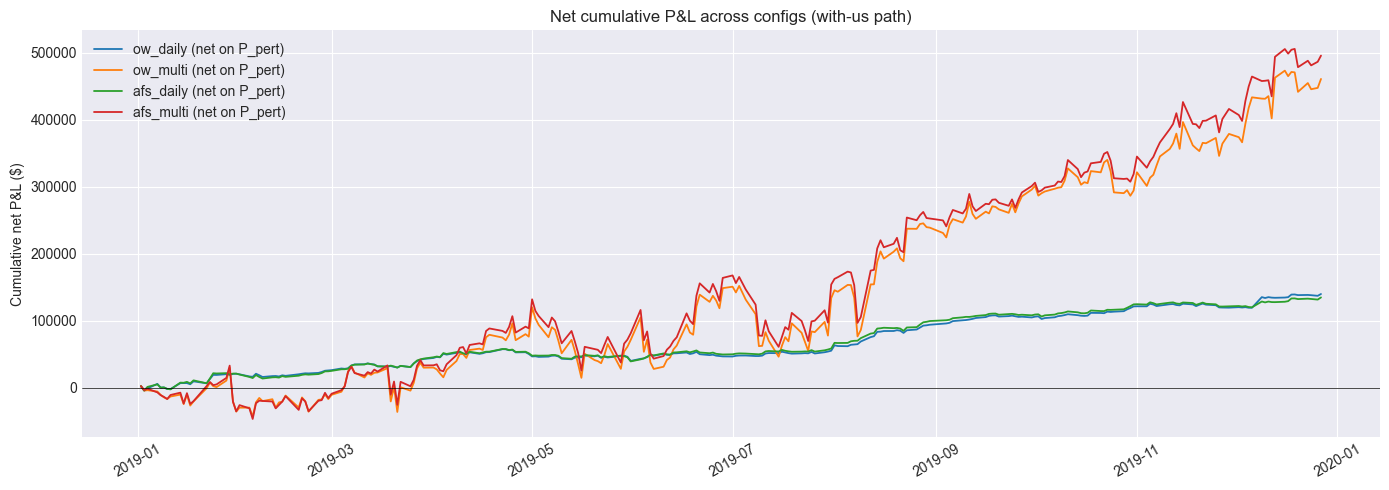

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
for name, out in runs.items():
    cum = pi.cumulative_pnl(out.daily, "pnl_pert")
    ax.plot(cum.index, cum.values, label=f"{name} (net on P_pert)", lw=1.3)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cumulative net P&L ($)")
ax.set_title("Net cumulative P&L across configs (with-us path)")
ax.legend()
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


### 7.4 Per-run artifacts

Each run wrote its plots, tables, config snapshot, and a sample price-path chart to `saved/<name>/`. The sample chart overlays observed mid, `P_unpert` (others only), `P_pert` (full aggregate), and the corresponding $g$ paths, so the perturbed/unperturbed comparison is directly accessible from `runs[name].paths["sample_price_paths_plot"]`.



=== saved/ow_daily/ ===
  config.json
  cum_pnl.png
  daily_pnl.csv
  drawdown.png
  impact_dislocation.png
  metrics.csv
  path_AMD_2019-10-07.png
  price_paths_AMD_2019-10-07.png
  stock_day_pnl.csv
  tca_stock_day.csv
  tca_summary.csv

=== saved/ow_multi/ ===
  config.json
  cum_pnl.png
  daily_pnl.csv
  drawdown.png
  impact_dislocation.png
  metrics.csv
  path_AMD_2019-10-07.png
  price_paths_AMD_2019-10-07.png
  stock_day_pnl.csv
  tca_stock_day.csv
  tca_summary.csv

=== saved/afs_daily/ ===
  config.json
  cum_pnl.png
  daily_pnl.csv
  drawdown.png
  impact_dislocation.png
  metrics.csv
  path_AMD_2019-10-07.png
  price_paths_AMD_2019-10-07.png
  stock_day_pnl.csv
  tca_stock_day.csv
  tca_summary.csv

=== saved/afs_multi/ ===
  config.json
  cum_pnl.png
  daily_pnl.csv
  drawdown.png
  impact_dislocation.png
  metrics.csv
  path_AMD_2019-10-07.png
  price_paths_AMD_2019-10-07.png
  stock_day_pnl.csv
  tca_stock_day.csv
  tca_summary.csv

Sample perturbed/unperturbed price-pa

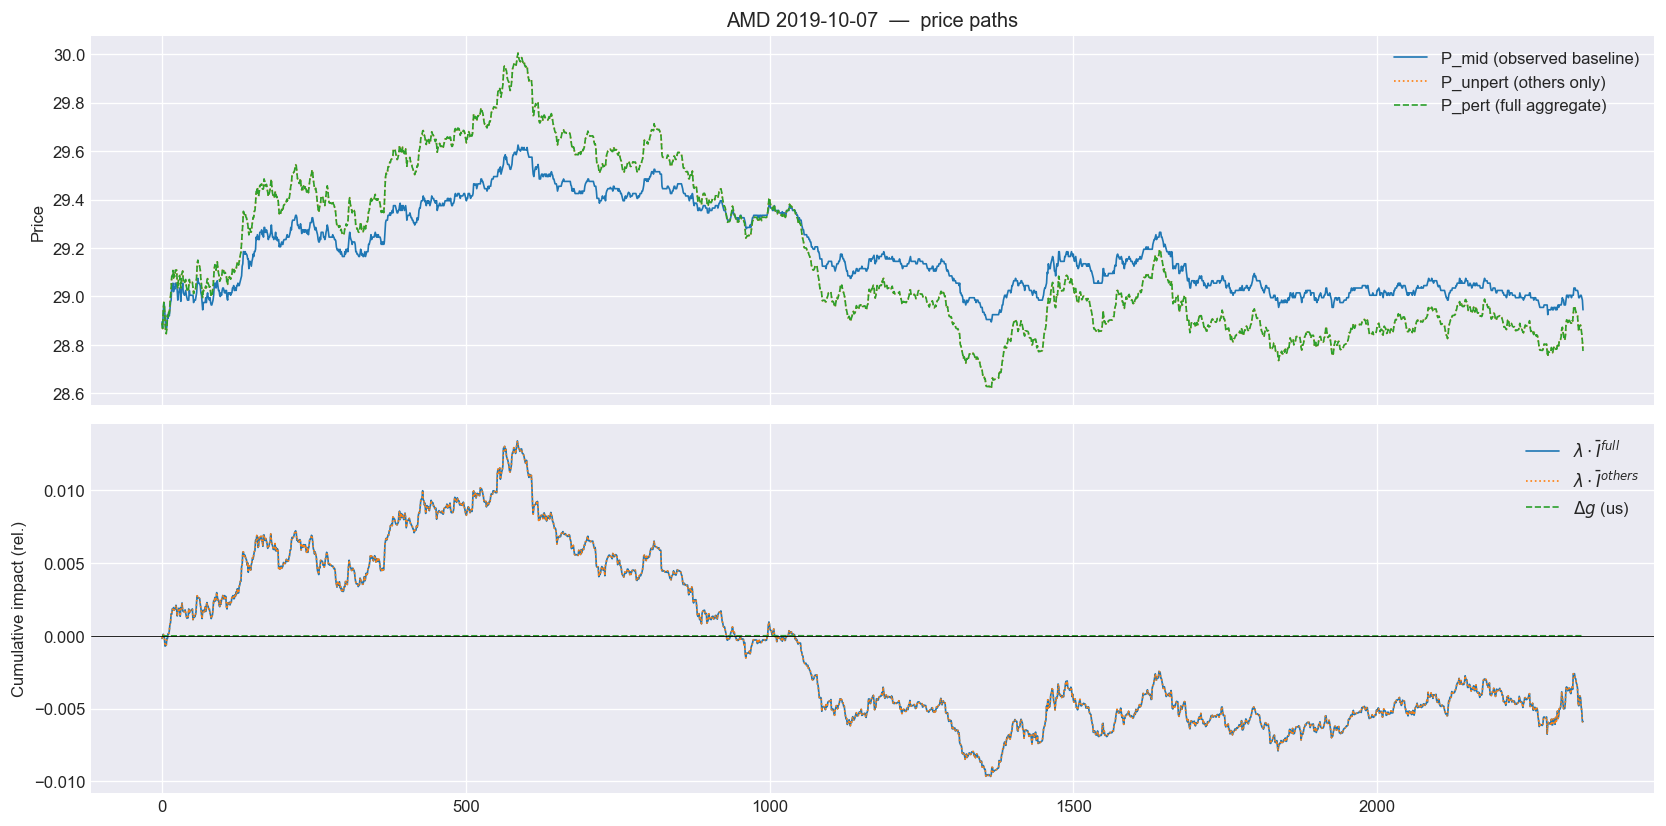

In [ ]:
import os
from IPython.display import Image, display

for name in runs:
    files = sorted(os.listdir(runs[name].paths["dir"]))
    print(f"\n=== saved/{name}/ ===")
    for f in files:
        print(" ", f)

price_path_plots = {
    name: out.paths.get("sample_price_paths_plot")
    for name, out in runs.items()
    if out.paths.get("sample_price_paths_plot") is not None
}

print("\nSample perturbed/unperturbed price-path plots:")
for name, path in price_path_plots.items():
    print(f"{name}: {path}")

# Display one example inline; all runs expose their plot paths above.
if price_path_plots:
    first_name, first_path = next(iter(price_path_plots.items()))
    print(f"\nDisplaying {first_name} sample price paths:")
    display(Image(filename=str(first_path)))


## Summary

All pipeline logic lives in `src/price_impact/` and is unit-friendly — the notebook itself is just orchestration. To add a new backtest, build a new `BacktestConfig` and call `run_and_save`; to plug in a custom strategy or a fixed schedule (TWAP / VWAP), pass a `trade_provider` to `run_backtest` and bypass `run_and_save`'s OW/AFS dispatch.

The implemented accounting is: aggregate flow `q_agg` comes from the tape, our flow `q_us` comes from the strategy, and residual flow is `q_others = q_agg - q_us`. Under the Waelbroeck map $P=P_0(1+R+\lambda\bar I)$, the unperturbed path uses $\bar I(q_{others})$, the perturbed path uses $\bar I(q_{agg})$, P&L/impact uses the perturbed path, and participation is implied directly by `q_us` versus bin/day volume.

Outstanding work:

- Wire the **extended OW** closed form (time-dependent $\lambda(t)$) into `strategy.ext_ow_optimal_strategy_timedep_lambda`. The simulator already accepts a per-bin $\lambda$ array in `lam_t_lookup`.
- If you want fully no-us rolling signals rather than the current explicit hybrid, run a two-pass/fixed-point workflow that first constructs a `p_unpert` panel, then calls `compute_daily_stats(..., price_col="p_unpert")`, `create_synthetic_alpha(..., price_col="p_unpert")`, and the fitting helpers with `price_col="p_unpert"`.
